# LAB ASSIGNMENT 3

## Group ID: AbNaPaAd

## Team Members:

1. Abhinav Reddy Gutha (2103102)
2. Nidamanuri Sai Adarsh (2103123)
3. Nalamolu Nagarjuna Viswanath (2103316)
4. Palika Babuji Powthra (2103124)

This lab assignment is about exploring some of the concepts like KMeans, Multivariate Guassian Distribution, EM Algorithm and Bayes Classifier and applying it in some of the real world applications like Image Compression, Image Segmentation and Hand Digit Recognition. Also here we have explored some new classifiers like Neyman Pearson Classifier and MinMax Classifier.

1. (K-means) Download the old faithful dataset. It is instructive to understand the origin of this dataset.
Implement K-means (you cannot use the inbuilt library) and recreate plots similar to Figure 9.1 and
Figure 9.2 from Bishop’s book.

2. (K-means for Image segmentation / Image compression) Pick a suitable image and apply clustering tech-
nique of the previous step to generate figures similar to Figure 9.3 from Bishop’s book. Read about Image segmentation and Image compression problems.

3. (Soft-assignment intuition) The objective of this exercise is to understand the multivariate gaussian dis-
tribution.

    (a) Refer to figure 2.23 in Bishop and generate the plots similar to that. As a self study, explore how covariance matrix changes the contours.

    (b) Generate 500 points from previous step clearing indicating the responsible cluster. Thereafter, generate figure 9.5 from Bishop.

4. (GMM EM) Generate Figure 9.8 using the Old Faithful.
5. (Unsupervised labeling) This exercise concerns the classdemo.py file shared with you. The EM algorithm learns the hidden parameters fairly well. This question asks you to classify every point to each coin. Record the error rate of this “classifier”.
6. (Auto labeling with EM) In practice, availability of labelled datasets is difficult. One approach is to cluster the dataset suitably and then retrospectively assign label to each cluster. Using the approach described in Figure 9.10 of Bishop cluster the MNIST dataset into 10 clusters using mixture of bernoulli distributions
and then examine the average cluster. Thereafter, each cluster is labelled based on the average cluster.
Record, how many points were misclassified based on this approach.
7. See this lecture (upto slide 14) https://developers.google.com/machine-learning/crash-course/classification/video-lecture. Design a bayes classifier (optimal) when p0 = 0.95. Also class conditional densities for class 0 is normal mean 0 and variance 1. For class 1, class conditional density is mean 1 and variance 1.

    (a) FP for bayes classifier

    (b) TP for bayes classifier

    (c) Accuracy

    (d) For the same setup implement Neyman Pearson Classifier.

    (e) Generate the ROC curve for various thresholds for the family of classifiers which classify based on likelihood ratio and a threshold as done in Neyman Pearson classifier.
    
    (f) Implement max-min classifier

## Question 1

### Importing Necessary Modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import tensorflow as tf
import os
import pandas as pd

#### Class for implementing KMeans and plotting the clusters

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
    def __init__(self, data, k, max_iterations=1000000, tol=1e-12):
        self.data = data
        self.length = len(data)
        self.k = k
        self.max_iterations = max_iterations
        self.tolerance = tol

        # Initialize centroids with specific values
        self.mus = [[3.25, 60], [3.25, 70]]

    def KMeansI(self):
        mus = np.array(self.mus)

        Z = np.zeros((self.length, self.k))
        self.plotClustersWithoutBisector(mus, Z)
        for _ in range(self.max_iterations):
            mus_old = mus.copy()

            # Update assignments and distances
            for i in range(self.length):
                dist = np.linalg.norm(self.data[i] - mus, axis=1)
                cluster = np.argmin(dist)
                Z[i] = np.eye(self.k)[cluster]

            self.plotClustersWithBisector(mus, Z)

            # Update centroids
            for j in range(self.k):
                num = np.zeros_like(self.data[0])
                dem = 0
                for i in range(self.length):
                    num += Z[i][j] * self.data[i]
                    dem += Z[i][j]
                mus[j] = num / dem if dem != 0 else np.zeros_like(self.data[0])

            self.plotClustersWithoutBisector(mus, Z)

            if np.max(np.abs(mus - mus_old)) < self.tolerance:
                break
        return mus, Z

    def KMeansII(self, k):
        Z = np.eye(k)[np.random.choice(k, self.length)]
        mus = np.zeros((k, self.data.shape[1]))

        for _ in range(self.max_iterations):
            mus_old = mus.copy()

            # Update centroids
            mus = np.dot(Z.T, self.data) / np.sum(Z, axis=0)[:, None]

            # Update assignments
            distances = np.linalg.norm(self.data[:, None] - mus, axis=2)
            Z = np.zeros_like(Z)
            Z[np.arange(self.length), np.argmin(distances, axis=1)] = 1

            if np.max(np.abs(mus - mus_old)) < self.tolerance:
                break

        return mus, Z

    def elbow(self, max_k):
        inertias = []
        for k in range(1, max_k + 1):
            mus, Z = self.KMeansII(k)
            inertia = 0
            for i in range(self.length):
                inertia += np.linalg.norm(self.data[i] - mus[np.argmax(Z[i])])**2
            inertias.append(inertia)

        # Plotting the elbow curve
        plt.plot(range(1, max_k + 1), inertias, marker='o')
        plt.xlabel('Number of clusters')
        plt.ylabel('Inertia')
        plt.title('Elbow Method')
        plt.show()




    def plotClustersWithBisector(self, mus, Z):
        plt.figure(figsize=(8, 6))
        for j in range(self.k):
            cluster_points = self.data[np.where(Z[:, j] == 1)]
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {j+1}', cmap='viridis')
        plt.scatter(mus[:, 0], mus[:, 1], marker='X', color='red', s=100, label='Centroids')

        # Calculate midpoint between centroids
        centroid_midpoint = np.mean(mus, axis=0)

        # Calculate slope of line connecting centroids
        centroid_slope = (mus[1, 1] - mus[0, 1]) / (mus[1, 0] - mus[0, 0])

        # Calculate negative reciprocal slope for perpendicular bisector
        bisector_slope = -1 / centroid_slope

        # Calculate y-intercept of perpendicular bisector passing through midpoint
        bisector_intercept = centroid_midpoint[1] - bisector_slope * centroid_midpoint[0]

        # Define x values for drawing perpendicular bisector line
        x_values = np.linspace(np.min(self.data[:, 0]), np.max(self.data[:, 0]), 100)
        # Calculate corresponding y values using the equation of the line
        y_values = bisector_slope * x_values + bisector_intercept

        plt.plot(x_values, y_values, color='blue', linestyle='--', label='Perpendicular Bisector')

        plt.xlabel('eruptions')
        plt.ylabel('waitings')
        plt.title('Old Faithful Clustering')
        plt.legend()
        plt.show()

    def plotClustersWithoutBisector(self, mus, Z):
        plt.figure(figsize=(8, 6))
        for j in range(self.k):
            cluster_points = self.data[np.where(Z[:, j] == 0)]
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {j+1}', cmap='viridis')
        plt.scatter(mus[:, 0], mus[:, 1], marker='X', color='red', s=100, label='Centroids')
        plt.xlabel('eruptions')
        plt.ylabel('waitings')
        plt.title('Old Faithful Clustering')
        plt.legend()
        plt.show()


### Getting the Old Faithful dataset using Kaggle APIs

In [ ]:
os.environ["KAGGLE_USERNAME"] = "abhinavreddygutha"
os.environ["KAGGLE_KEY"] = "6ed6c2699643f5946cb44c75ccf9ae57"

In [ ]:
!kaggle datasets download -d janithwanni/old-faithful

old-faithful.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip old-faithful.zip

Archive:  old-faithful.zip
replace faithful.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
data = pd.read_csv('faithful.csv')

In [ ]:
data = data.drop(["Unnamed: 0"], axis=1)

In [ ]:
data = data.to_numpy()

### Applying K Means Algorithm to the dataset keeping the value of K as 2

In [ ]:
kmeans = KMeans(data, 2)

<ipython-input-83-549b4ef52ab6>:121: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {j+1}', cmap='viridis')


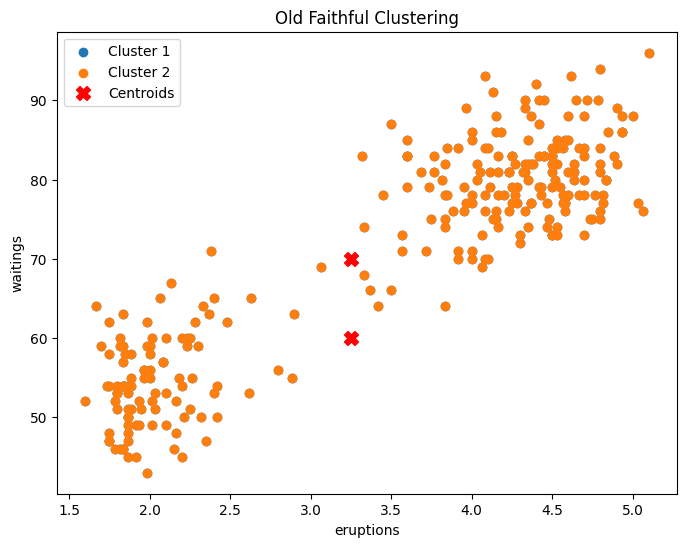

<ipython-input-83-549b4ef52ab6>:89: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {j+1}', cmap='viridis')
<ipython-input-83-549b4ef52ab6>:96: RuntimeWarning: divide by zero encountered in scalar divide
  centroid_slope = (mus[1, 1] - mus[0, 1]) / (mus[1, 0] - mus[0, 0])


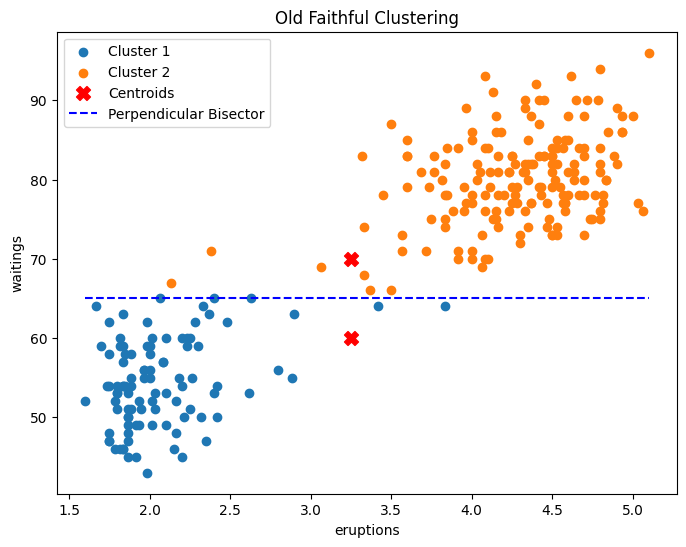

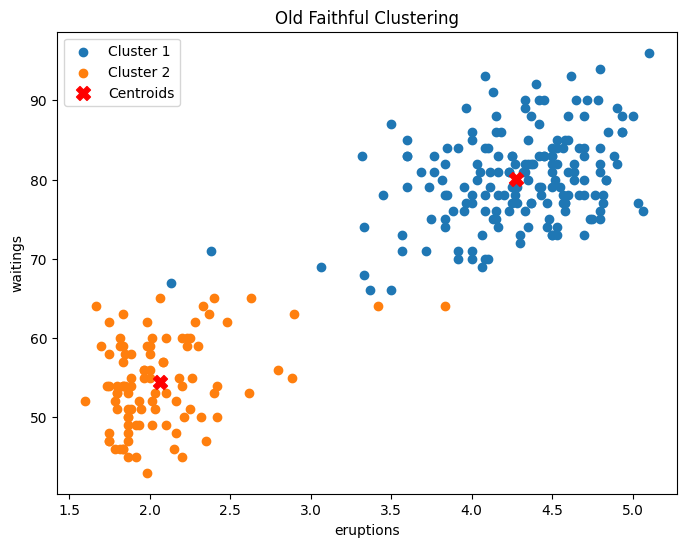

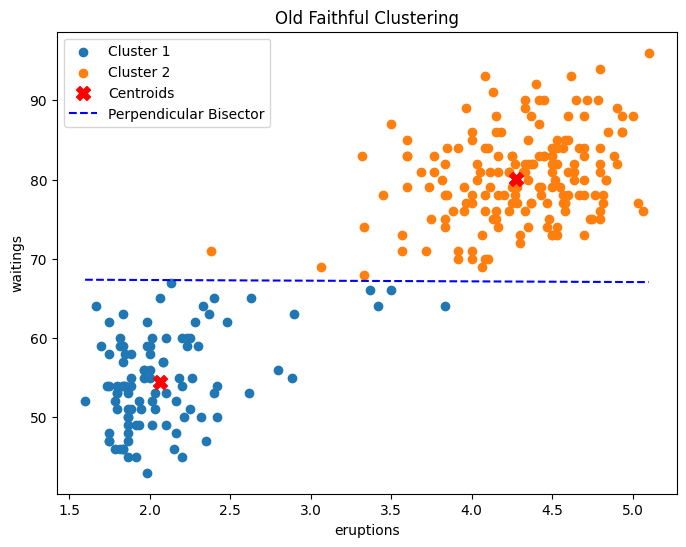

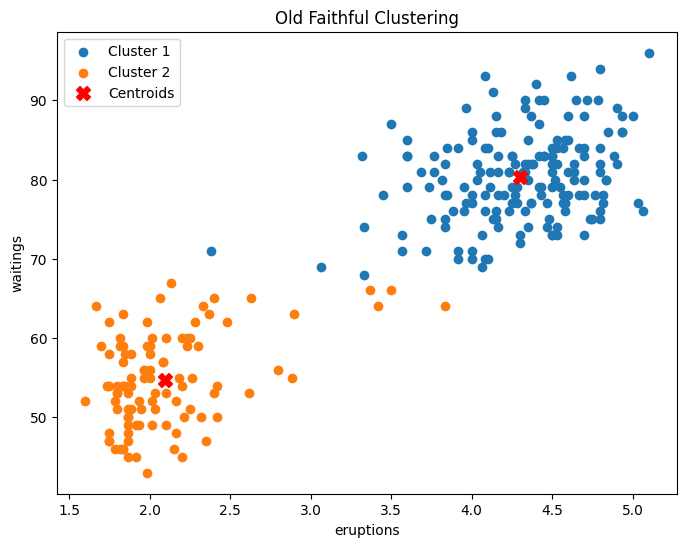

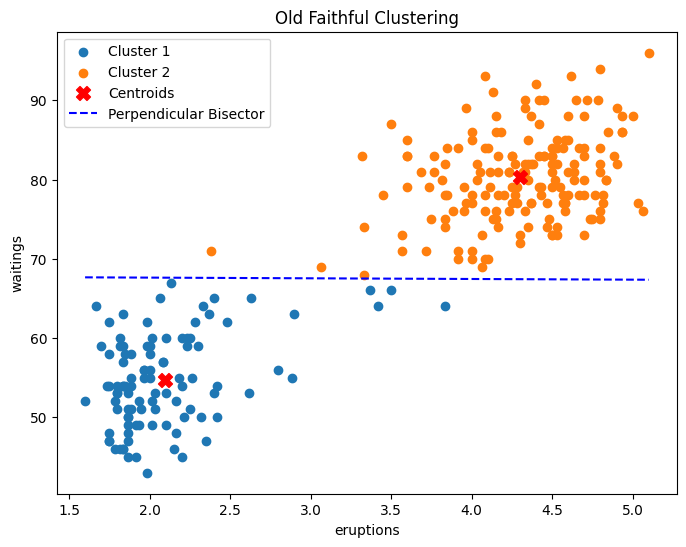

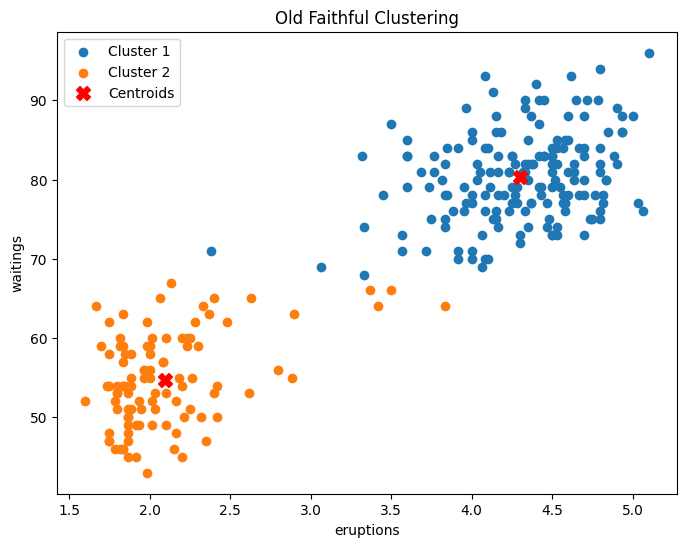

In [ ]:
mus, Z = kmeans.KMeansI()

### Generating the Elbow Curve for the dataset

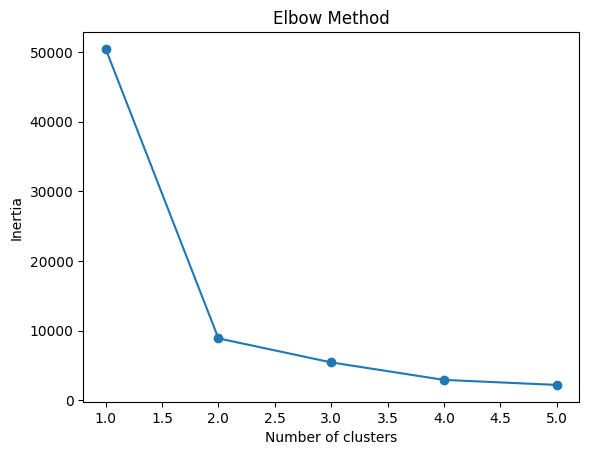

In [ ]:
kmeans.elbow(5)

## Question 2

### Importing necessary Modules

In [ ]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt,sklearn,random
from tqdm import tqdm

### Class for implementing image compression and segmentation code

In [ ]:
class KMeansC:
    def __init__(self, inputfilename, outputfilename, k, max_iterations=100, tol=1e-12):
        random.seed(42)
        self.data = plt.imread(inputfilename)
        self.xdim, self.ydim, _ = self.data.shape
        self.data = self.data.reshape(-1, 3)
        self.inputfilename = inputfilename
        self.outputfilename = outputfilename
        self.length = len(self.data)
        self.k = k
        self.max_iterations = max_iterations
        self.tolerance = tol
        self.mus = self.data[np.random.choice(self.data.shape[0], size=k, replace=False)]
        self.Z_final = None
        self.mus_final = None
        self.compressedImage = None

    def KMeansI(self):
      mus = np.array(self.mus)
      Z = np.zeros((self.length, self.k))
      for _ in tqdm(range(self.max_iterations)):
          mus_old = mus.copy()
          dist = np.linalg.norm(self.data[:, np.newaxis, :] - mus, axis=2)
          cluster = np.argmin(dist, axis=1)
          Z = np.eye(self.k)[cluster]
          num = np.dot(Z.T, self.data)
          dem = np.sum(Z, axis=0)
          dem = dem.reshape(-1, 1)
          mus = np.where(dem != 0, num / dem, mus)

          if np.max(np.abs(mus - mus_old)) < self.tolerance:
              break

      self.mus_final = mus
      self.Z_final = Z
      return mus, Z


    def compressImage(self):
        self.KMeansI()
        modified_image = self.data.copy()
        assignments = np.argmax(self.Z_final, axis=1)
        print("Image Compression in progress:")
        for i in tqdm(range(len(modified_image))):
            modified_image[i] = self.mus_final[assignments[i]]
        self.compressedImage = modified_image.copy()
        plt.imsave(self.outputfilename, self.compressedImage.reshape(self.xdim,self.ydim,3))
    def segmentImage(self):
        self.KMeansI()
        modified_image = self.data.copy()
        assignments = np.argmax(self.Z_final, axis=1)
        print("Image Segmentation in progress:")
        for i in tqdm(range(len(modified_image))):
            modified_image[i] = self.mus_final[assignments[i]]
        self.compressedImage = modified_image.copy()
        plt.imsave(self.outputfilename, self.compressedImage.reshape(self.xdim,self.ydim,3))

### Function which gets the size of the file

In [ ]:
inputfilename = "/content/car.jpg"
outputfilename = "./compressed.jpg"
compressor = KMeansC(inputfilename,outputfilename,50)
import os
def get_file_size(file_path):
    try:
        file_size = os.path.getsize(file_path)
        def format_size(size):
            for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
                if size < 1024.0:
                    return f"{size:.2f} {unit}"
                size /= 1024.0

        return format_size(file_size)
    except FileNotFoundError:
        return "File not found"
    except Exception as e:
        return f"Error: {str(e)}"

### Compressing the image keeping the value of k as 50

In [ ]:
compressor.compressImage()

100%|██████████| 100/100 [01:18<00:00,  1.27it/s]


Image Compression in progress:


100%|██████████| 203138/203138 [00:00<00:00, 752930.81it/s]


In [ ]:
print("Initial size of image:",get_file_size(inputfilename))
print("Final size of image after compression:",get_file_size(outputfilename))

Initial size of image: 38.53 KB
Final size of image after compression: 32.21 KB


array([[[ 94, 181, 224],
        [ 95, 182, 225],
        [ 96, 183, 226],
        ...,
        [ 76, 173, 218],
        [ 78, 175, 218],
        [ 78, 175, 217]],

       [[ 91, 178, 223],
        [ 93, 180, 225],
        [ 94, 181, 226],
        ...,
        [ 77, 174, 219],
        [ 78, 175, 218],
        [ 78, 175, 217]],

       [[ 89, 176, 221],
        [ 90, 177, 222],
        [ 91, 180, 224],
        ...,
        [ 78, 174, 222],
        [ 78, 175, 218],
        [ 78, 175, 218]],

       ...,

       [[ 94, 104, 106],
        [ 74,  84,  86],
        [ 46,  56,  58],
        ...,
        [ 50,  60,  62],
        [ 71,  81,  83],
        [ 71,  81,  83]],

       [[ 71,  81,  83],
        [ 63,  73,  75],
        [ 75,  85,  87],
        ...,
        [ 82,  92,  94],
        [ 71,  81,  83],
        [ 70,  80,  82]],

       [[ 99, 109, 111],
        [ 75,  85,  87],
        [ 82,  92,  94],
        ...,
        [ 40,  50,  52],
        [ 81,  89,  92],
        [ 82,  90,  93]]], dtype=uint8)
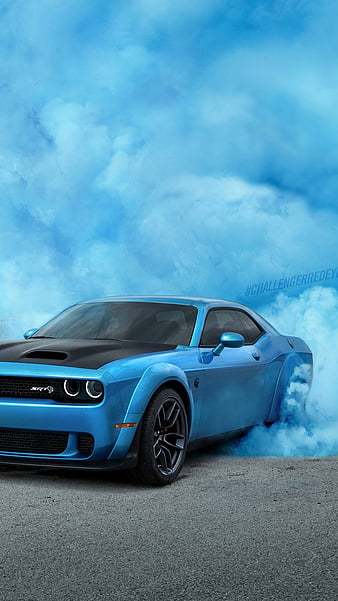

In [ ]:
plt.imread(inputfilename)

array([[[ 95, 182, 225],
        [ 96, 183, 226],
        [ 98, 185, 228],
        ...,
        [ 72, 170, 215],
        [ 73, 170, 215],
        [ 73, 170, 215]],

       [[ 91, 178, 221],
        [ 93, 180, 223],
        [ 94, 181, 224],
        ...,
        [ 74, 172, 217],
        [ 75, 172, 217],
        [ 75, 172, 217]],

       [[ 87, 176, 218],
        [ 89, 178, 220],
        [ 90, 179, 223],
        ...,
        [ 77, 175, 220],
        [ 75, 172, 217],
        [ 75, 172, 217]],

       ...,

       [[ 84,  95,  97],
        [ 69,  80,  82],
        [ 36,  47,  49],
        ...,
        [ 33,  44,  46],
        [ 68,  79,  81],
        [ 68,  79,  81]],

       [[ 72,  83,  85],
        [ 64,  75,  77],
        [ 78,  89,  91],
        ...,
        [ 86,  97,  99],
        [ 66,  77,  79],
        [ 66,  77,  79]],

       [[102, 113, 115],
        [ 79,  90,  92],
        [ 78,  89,  91],
        ...,
        [ 36,  47,  49],
        [ 79,  90,  92],
        [ 79,  90,  92]]], dtype=uint8)
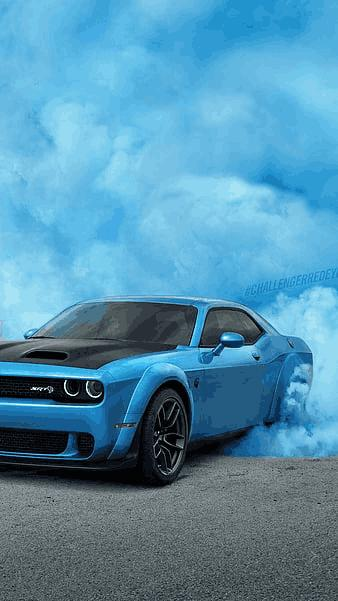

In [ ]:
plt.imread(outputfilename)

### Implementing Image Segmentation keeping the value of K as multiples of 2

  6%|▌         | 6/100 [00:00<00:03, 26.39it/s]


Image Segmentation in progress:


 27%|██▋       | 27/100 [00:01<00:04, 18.21it/s]


Image Segmentation in progress:


 37%|███▋      | 37/100 [00:04<00:08,  7.73it/s]


Image Segmentation in progress:


100%|██████████| 100/100 [00:25<00:00,  3.85it/s]


Image Segmentation in progress:


100%|██████████| 203138/203138 [00:00<00:00, 728987.01it/s]


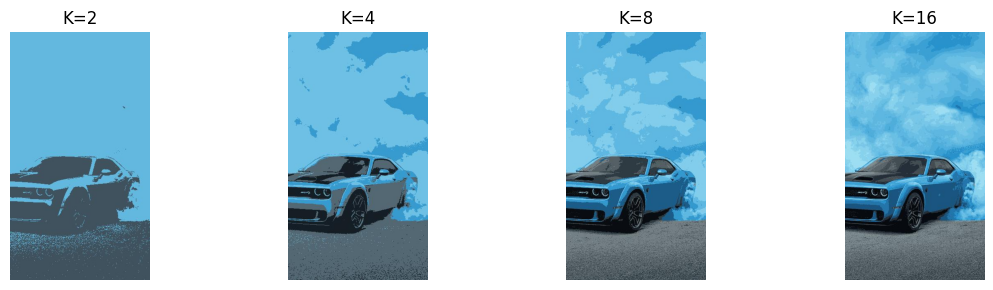

In [ ]:
inputfilename = "/content/car.jpg"
outputfilename = "./segmented"
k_values = [2, 4, 8, 16]
for k in k_values:
    compressor = KMeansC(inputfilename, f"{outputfilename}_{k}.jpg", k)
    compressor.segmentImage()
num_rows = 1
num_cols = len(k_values)
plt.figure(figsize=(3*num_cols, 3*num_rows))
for i, k in enumerate(k_values):
    plt.subplot(num_rows, num_cols, i+1)
    plt.imshow(plt.imread(f"{outputfilename}_{k}.jpg"))
    plt.title(f"K={k}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Question 3

### Importing Necessary Modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import seaborn as sns

In [ ]:
def multivariate_gaussian(x, mean, covariance):
    n = len(mean)
    exponent = -0.5 * np.dot(np.dot((x - mean).T, np.linalg.inv(covariance)), (x - mean))
    coefficient = 1 / (np.sqrt((2 * np.pi) ** n * np.linalg.det(covariance)))
    pdf = coefficient * np.exp(exponent)
    return pdf

## This class will have all the necessary functions needed to get all plots asked in the question

In [ ]:
class GaussianDistributions:

    def __init__(self, pi1, mean1, covariance1, pi2, mean2, covariance2, pi3, mean3, covariance3):
        self.pi1 = pi1
        self.mean1 = mean1
        self.covariance1 = covariance1
        self.pi2 = pi2
        self.mean2 = mean2
        self.covariance2 = covariance2
        self.pi3 = pi3
        self.mean3 = mean3
        self.covariance3 = covariance3

    def multivariate_gaussian(self, x, mean, covariance):
        n = len(mean)
        exponent = -0.5 * np.dot(np.dot((x - mean).T, np.linalg.inv(covariance)), (x - mean))
        coefficient = 1 / (np.sqrt((2 * np.pi) ** n * np.linalg.det(covariance)))
        pdf = coefficient * np.exp(exponent)
        return pdf

    def getpdfValues(self, X, mean, covariance):
        n = len(X)
        z = []
        for i in range(n):
            pdf = self.multivariate_gaussian(X[i], mean, covariance)
            z.append(pdf)
        z = np.array(z)
        return z

    def generateContours(self):
        x, y = np.mgrid[-0.5:1.5:.05, -0.5:1.5:.05]
        data = np.column_stack([x.flat, y.flat])
        z1 = self.getpdfValues(data, self.mean1, self.covariance1).reshape(x.shape)
        z2 = self.getpdfValues(data, self.mean2, self.covariance2).reshape(x.shape)
        z3 = self.getpdfValues(data, self.mean3, self.covariance3).reshape(x.shape)

        plt.contour(x, y, z1, colors='red')
        plt.contour(x, y, z2, colors='green')
        plt.contour(x, y, z3, colors='blue')

        plt.show()

    def MixtureDistributioncontours(self):
        x, y = np.mgrid[-0.5:1.5:.05, -0.5:1.5:.05]
        data = np.column_stack([x.flat, y.flat])
        z1 = self.getpdfValues(data, self.mean1, self.covariance1).reshape(x.shape)
        z2 = self.getpdfValues(data, self.mean2, self.covariance2).reshape(x.shape)
        z3 = self.getpdfValues(data, self.mean3, self.covariance3).reshape(x.shape)
        z = self.pi1 * z1 + self.pi2 * z2 + self.pi3 * z3

        plt.contour(x, y, z, colors='pink')
        plt.show()

    def surfacePlots(self):
        x, y = np.mgrid[-0.5:1.5:.05, -0.5:1.5:.05]
        data = np.column_stack([x.flat, y.flat])
        z1 = self.getpdfValues(data, self.mean1, self.covariance1).reshape(x.shape)
        z2 = self.getpdfValues(data, self.mean2, self.covariance2).reshape(x.shape)
        z3 = self.getpdfValues(data, self.mean3, self.covariance3).reshape(x.shape)
        z = self.pi1 * z1 + self.pi2 * z2 + self.pi3 * z3

        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(x, y, z, cmap='viridis')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        fig.colorbar(surf)
        plt.show()


    def generate500Points(self):
        c1_pts = 250
        c2_pts = 150
        c3_pts = 100
        points = []
        ClusteredPoints = []

        for i in range(c1_pts):
            point = np.random.multivariate_normal(self.mean1, self.covariance1, 1)
            points.append(point[0])
            point = np.append(point, 1)
            ClusteredPoints.append(point)
        for i in range(c2_pts):
            point = np.random.multivariate_normal(self.mean2, self.covariance2, 1)
            points.append(point[0])
            point = np.append(point, 2)
            ClusteredPoints.append(point)
        for i in range(c3_pts):
            point = np.random.multivariate_normal(self.mean3, self.covariance3, 1)
            points.append(point[0])
            point = np.append(point, 3)
            ClusteredPoints.append(point)
        points = np.array(points)
        ClusteredPoints = np.array(ClusteredPoints)
        points = np.random.permutation(points)
        ClusteredPoints = np.random.permutation(ClusteredPoints)

        gamma = np.zeros((500, 3))
        n = len(points)
        for i in range(n):
          gamma[i][0] = self.pi1 * self.multivariate_gaussian(points[i], self.mean1, self.covariance1)
          gamma[i][1] = self.pi2 * self.multivariate_gaussian(points[i], self.mean2, self.covariance2)
          gamma[i][2] = self.pi3 * self.multivariate_gaussian(points[i], self.mean3, self.covariance3)
          sum = gamma[i][0] + gamma[i][1] + gamma[i][2]
          gamma[i][0] /= sum
          gamma[i][1] /= sum
          gamma[i][2] /= sum

        return points, ClusteredPoints, gamma


    def clusterPlot(self):
        points, ClusteredPoints, gamma = self.generate500Points()
        self.points = points
        self.ClusteredPoints = ClusteredPoints
        num_clusters = int(np.max(ClusteredPoints[:, -1]))
        plt.figure(figsize=(8, 6))
        colors = ['red', 'green', 'blue']
        for i in range(1, num_clusters + 1):
            region = ClusteredPoints[ClusteredPoints[:, -1] == i]
            plt.scatter(region[:, 0], region[:, 1], label=f'Region {i}', color=colors[i-1])
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Marginal Distribution obtained by using Zij values')
        plt.legend()
        plt.grid(True)
        plt.show()

        x = points[:, 0]
        y = points[:, 1]
        plt.scatter(x, y, s=20, c='#FF1493')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Marginal Distribution obtained by ignoring the values of Zij values')
        plt.grid(True)
        plt.show()

        x = self.points[:, 0]
        y = self.points[:, 1]
        plt.scatter(x, y, s=20, facecolors=gamma)
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('Samples in which the colours represent the value of the responsibilities γ(znk) associated with data point xn')
        plt.grid(True)
        plt.show()

### Choosing the values of Pis, Mean and covariance matrices of all 3 distributions

In [ ]:
pi1 = 0.5
mean1 = np.array([0.2,0.30])
covariance1 = np.array([[0.01, 0.005], [0.01, 0.02]])

pi2 = 0.3
mean2 = np.array([0.5,0.4])
covariance2 = np.array([[0.01, -0.015],[-0.005,  0.03]])

pi3 = 0.2
mean3 = np.array([0.8,0.45])
covariance3 = np.array([[0.01, 0.005],[0.01, 0.02]])

question3 = GaussianDistributions(pi1, mean1, covariance1, pi2, mean2, covariance2, pi3, mean3, covariance3)

### Contours of constant density for each of the mixture components, in which the 3 components are denoted red, blue and green, and the values of the mixing coefficients are shown below each component.

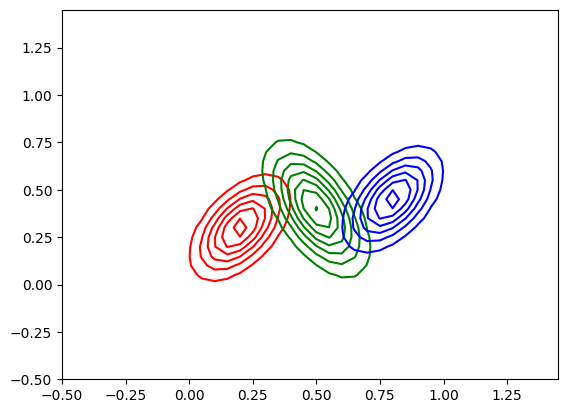

In [ ]:
question3.generateContours()

### Contours of the marginal probability density p(x) of the mixture distribution.

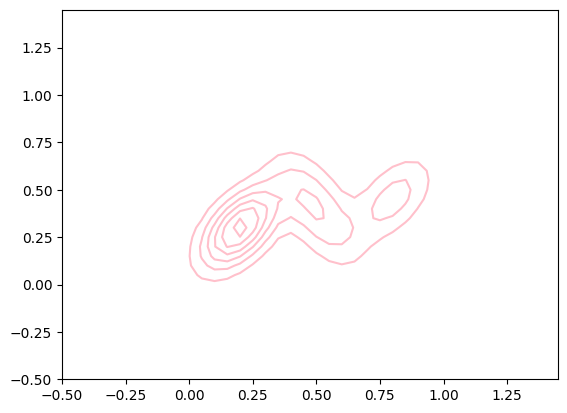

In [ ]:
question3.MixtureDistributioncontours()

### A surface plot of the distribution p(x).

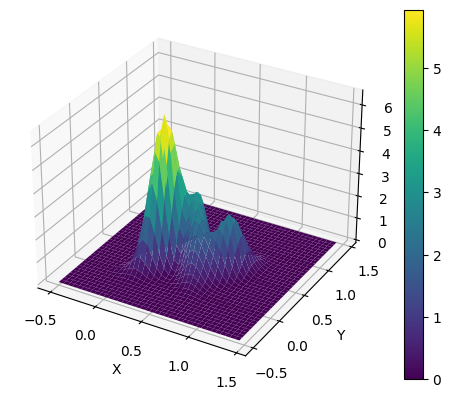

In [ ]:
question3.surfacePlots()

### Point Clustering with and without using the values of Zij's

<ipython-input-103-ad1caa8c46cc>:80: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  point = np.random.multivariate_normal(self.mean1, self.covariance1, 1)
<ipython-input-103-ad1caa8c46cc>:85: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  point = np.random.multivariate_normal(self.mean2, self.covariance2, 1)
<ipython-input-103-ad1caa8c46cc>:90: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  point = np.random.multivariate_normal(self.mean3, self.covariance3, 1)


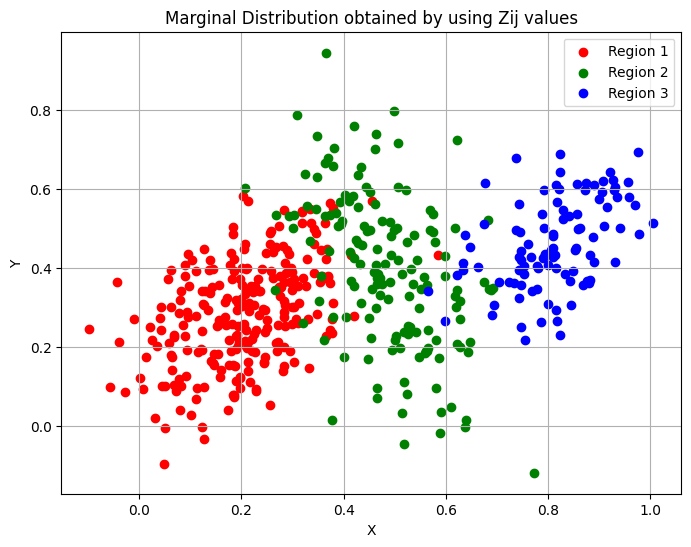

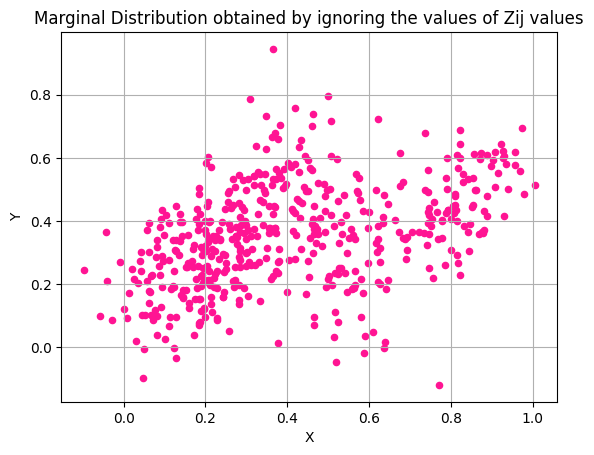

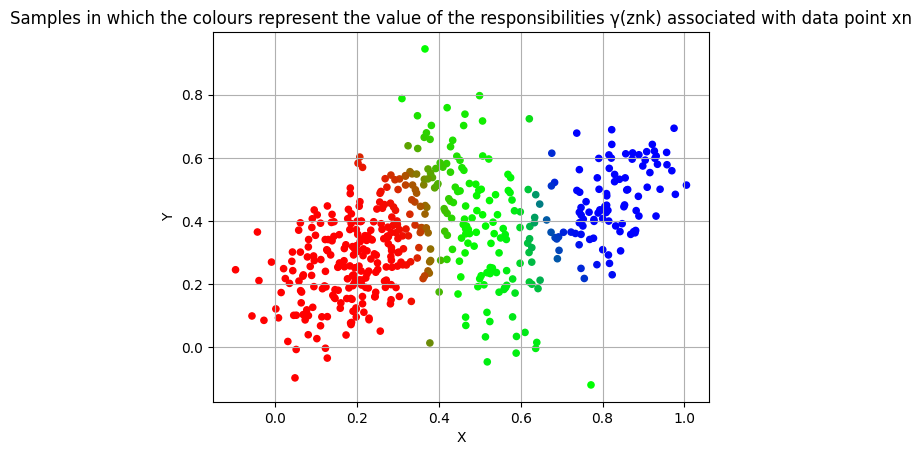

In [ ]:
question3.clusterPlot()

## Question 4

### Importing the Necessary Modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
import tensorflow as tf
import os
import pandas as pd

## This class will help us to implement EM Algorithm and generate plots at each iteration

In [ ]:
class EMAlgo:

  def __init__(self, data, k, max_iter=1000000000, tol=1e-12):
    self.data = data
    self.k = k
    self.max_iter = max_iter
    self.tol = tol

  def initialize_parameters(self):
    n, d = self.data.shape
    mus = [[3.25, 60], [3.25, 70]]
    sigmas = np.array([np.eye(d) for _ in range(self.k)])
    Pis = np.array([0.5, 0.5])
    return mus, sigmas, Pis

  def expectation_step(self, mus, sigmas, Pis):
    k = len(mus)
    n = len(self.data)
    d = data.shape[1]
    gamma = np.zeros((n, k))

    for i in range(k):
        gamma[:, i] = Pis[i] * multivariate_normal.pdf(data, mean=mus[i], cov=sigmas[i])

    gamma = gamma / np.sum(gamma, axis=1, keepdims=True)

    return gamma

  def maximization_step(self, gamma):
    n, d = self.data.shape

    Nk = np.sum(gamma, axis=0)

    mus = np.dot(gamma.T, self.data) / Nk[:, None]

    sigmas = np.zeros((self.k, d, d))
    for i in range(self.k):
        diff = self.data - mus[i]
        cov_sum = np.zeros((d, d))
        for j in range(n):
            cov_sum += gamma[j, i] * (diff[j].reshape(-1, 1) @ diff[j].reshape(1, -1))
        sigmas[i] = cov_sum / Nk[i]

    Pis = Nk / n

    return mus, sigmas, Pis

  def calculate_parameter_change(self, old_parameters, new_parameters):
    parameter_change = sum(np.linalg.norm(old_param - new_param) for old_param, new_param in zip(old_parameters, new_parameters))
    return parameter_change

  def run(self):
    mus, sigmas, Pis = self.initialize_parameters()

    prev_parameters = (mus.copy(), sigmas.copy(), Pis.copy())
    for i in range(self.max_iter):
        gamma = self.expectation_step(mus, sigmas, Pis)
        self.getClusteringUsingGammas(gamma)
        mus, sigmas, Pis = self.maximization_step(gamma)
        self.getClusteringUsingThetas(mus, sigmas, Pis, gamma)


        parameter_change = self.calculate_parameter_change(prev_parameters, (mus, sigmas, Pis))
        if parameter_change < self.tol:
            break

        prev_parameters = (mus.copy(), sigmas.copy(), Pis.copy())

    return mus, sigmas, Pis, gamma

  def getClusteringUsingGammas(self, gamma):
    x = self.data[:, 0]
    y = self.data[:, 1]

    colors = []
    for val in gamma:
        red_val = val[0]
        blue_val = val[1]
        color = (red_val, 0, blue_val)
        colors.append(color)

    plt.scatter(x, y, s=20, facecolors=colors)
    plt.grid(True)
    plt.show()

  def getClusteringUsingThetas(self, mus, sigmas, Pis, gamma):
      x = self.data[:, 0]
      y = self.data[:, 1]

      colors = []
      for val in gamma:
          red_val = val[0]
          blue_val = val[1]
          color = (red_val, 0, blue_val)
          colors.append(color)

      plt.scatter(x, y, s=20, facecolors=colors)

      x_range = np.linspace(min(x) - 1, max(x) + 1, 100)
      y_range = np.linspace(min(y) - 1, max(y) + 1, 100)
      X, Y = np.meshgrid(x_range, y_range)
      pos = np.empty(X.shape + (2,))
      pos[:, :, 0] = X
      pos[:, :, 1] = Y

      for mu, sigma, Pi in zip(mus, sigmas, Pis):
          rv = multivariate_normal(mu, sigma)
          Z = rv.pdf(pos)
          plt.contour(X, Y, Z, colors='k', linestyles='dashed')

      plt.grid(True)
      plt.show()

### Getting the Old Faithful dataset using Kaggle APIs

In [ ]:
os.environ["KAGGLE_USERNAME"] = "abhinavreddygutha"
os.environ["KAGGLE_KEY"] = "6ed6c2699643f5946cb44c75ccf9ae57"

In [ ]:
!kaggle datasets download -d janithwanni/old-faithful

old-faithful.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip old-faithful.zip

Archive:  old-faithful.zip
replace faithful.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Y
  inflating: faithful.csv            


In [ ]:
data = pd.read_csv('faithful.csv')

In [ ]:
data = data.drop(["Unnamed: 0"], axis=1)

In [ ]:
data = data.to_numpy()

### Implementing the EM Algorithm

In [ ]:
emAlgo =  EMAlgo(data, 2)

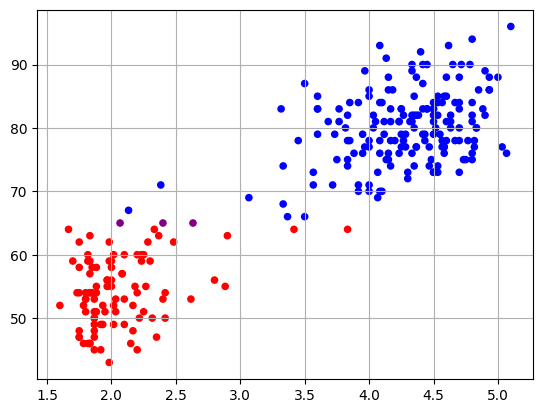

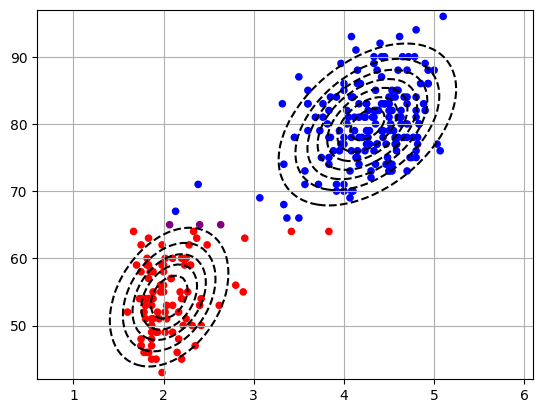

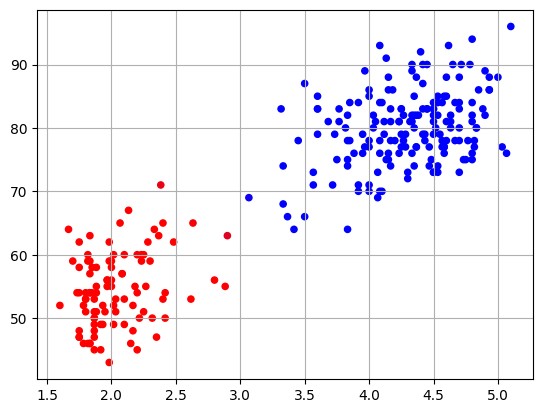

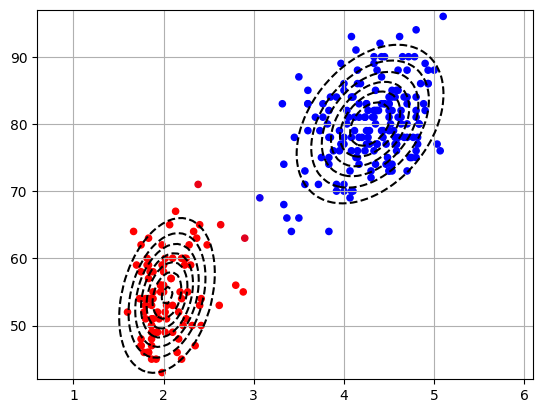

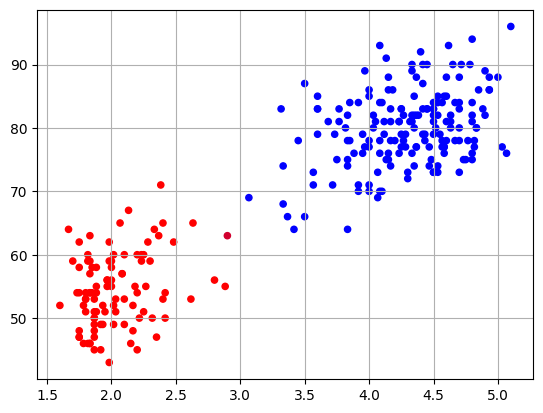

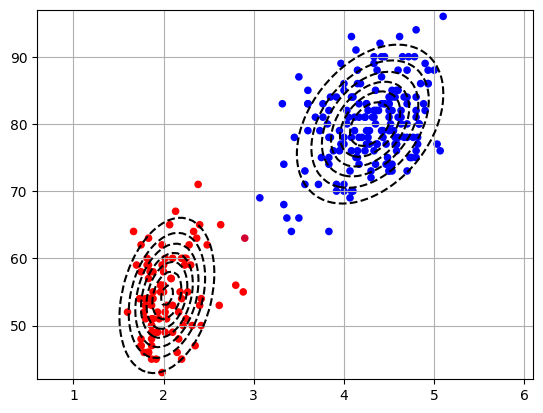

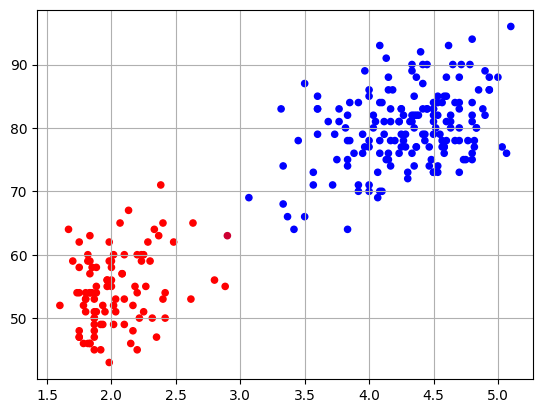

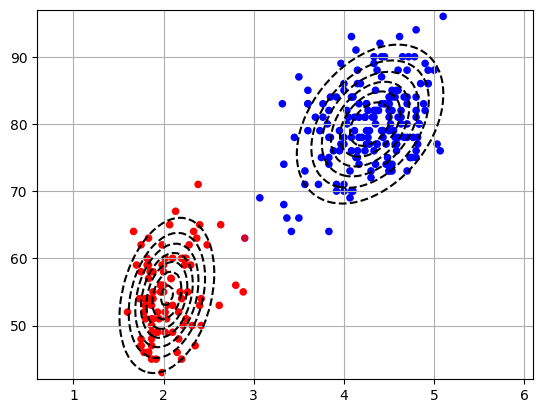

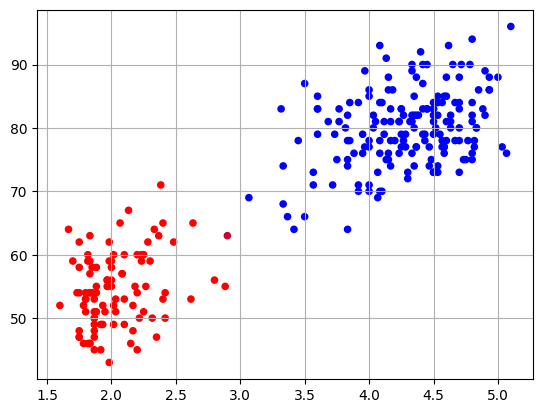

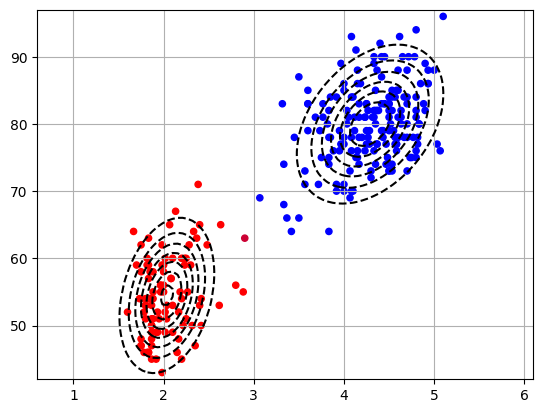

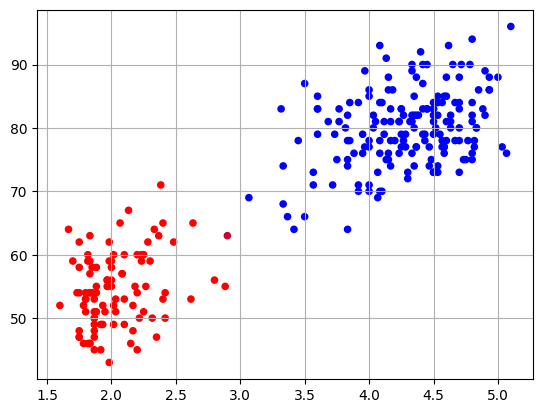

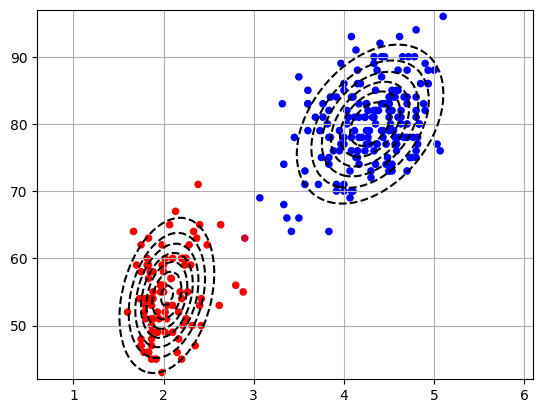

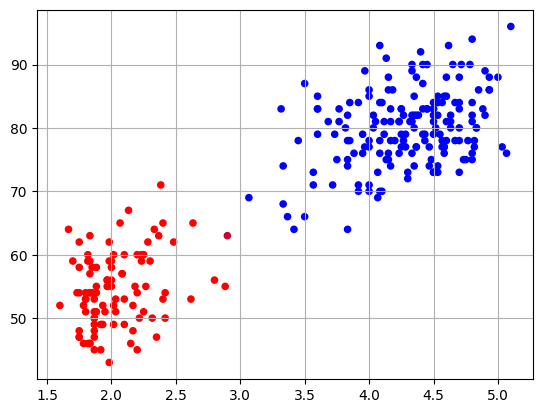

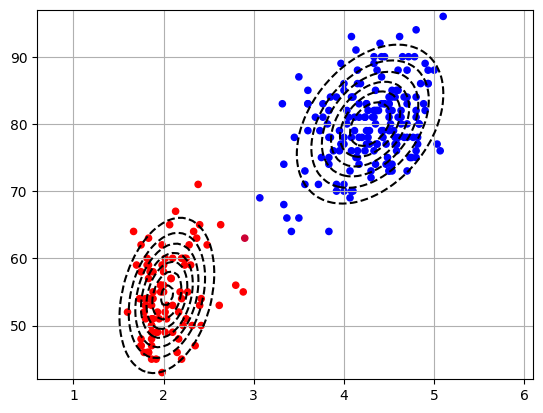

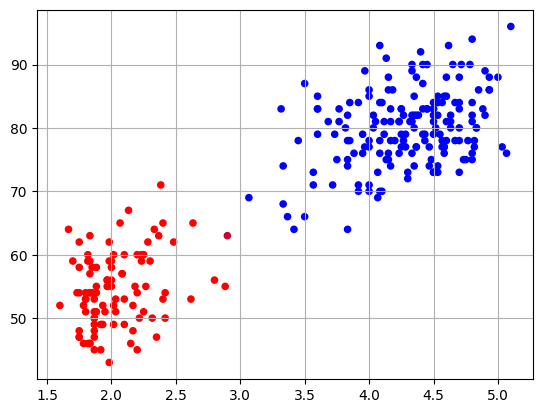

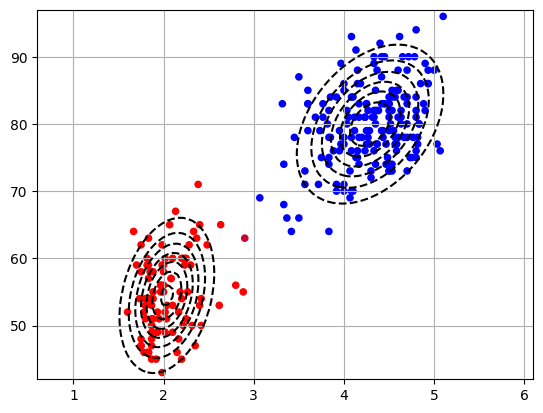

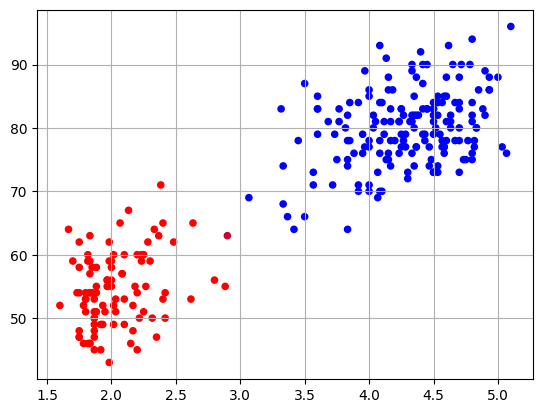

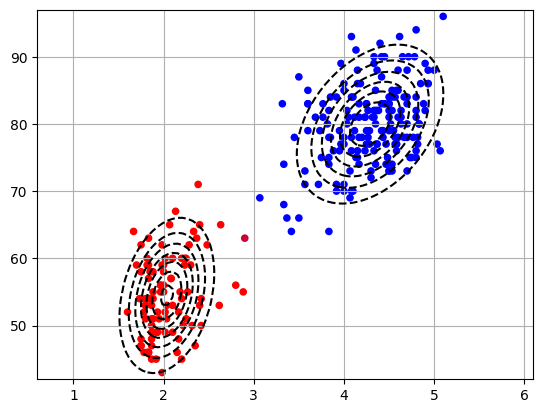

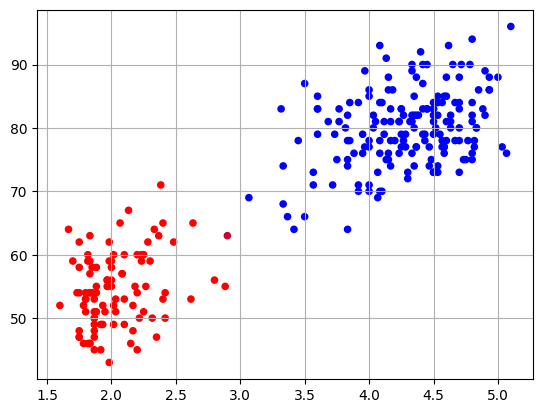

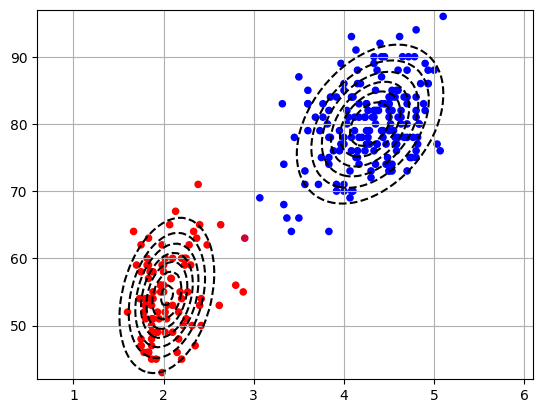

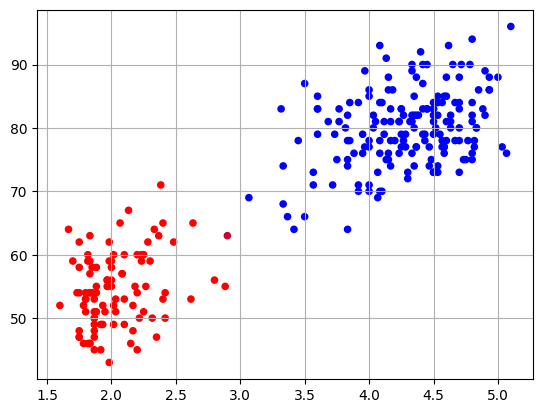

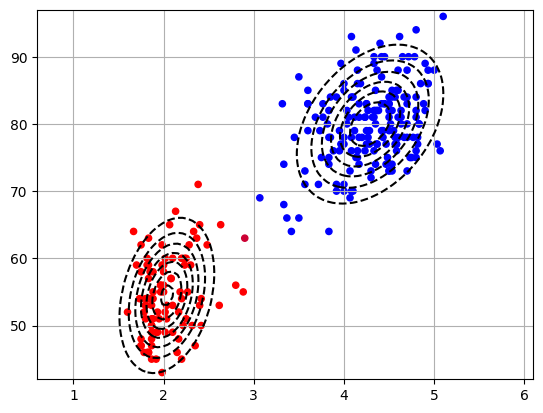

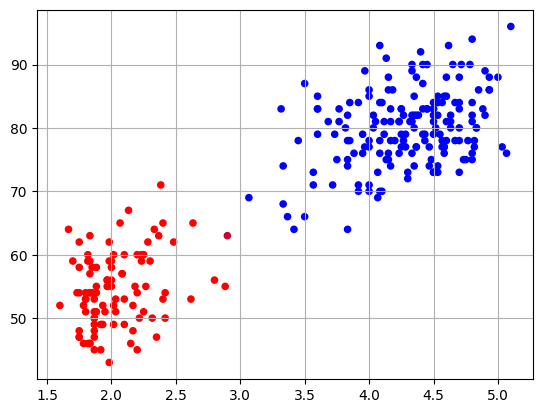

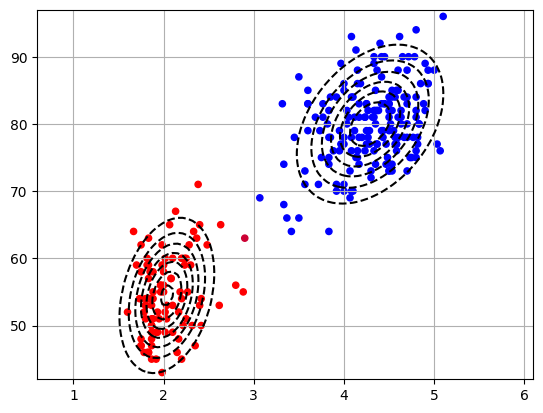

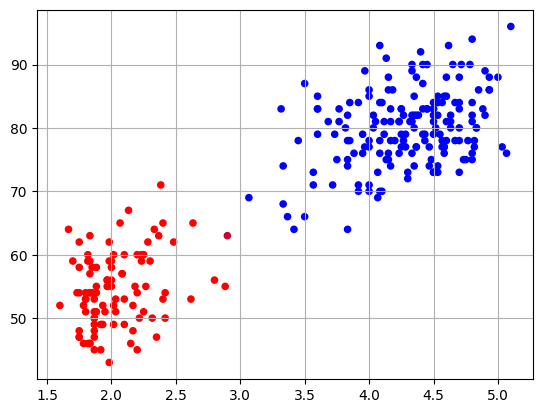

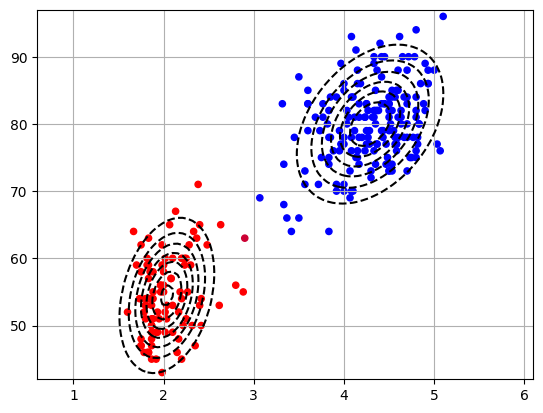

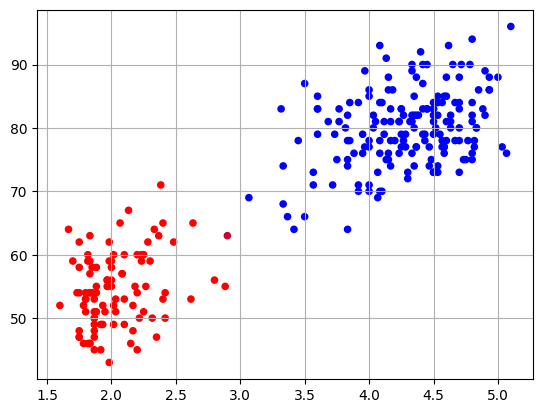

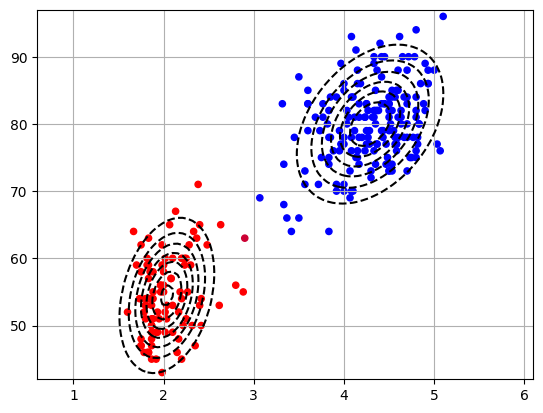

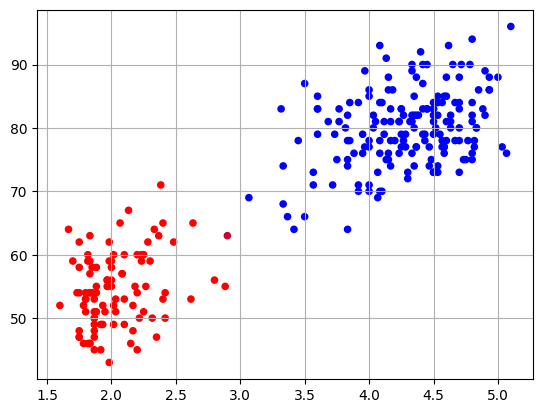

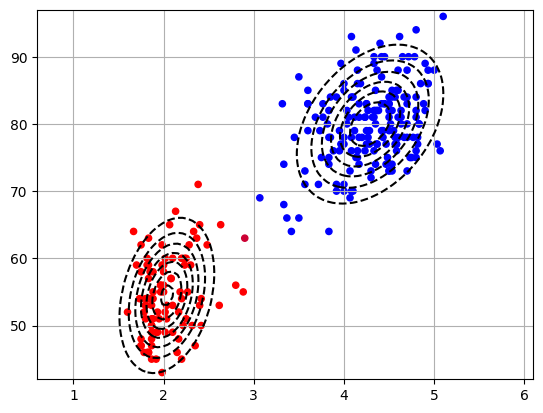

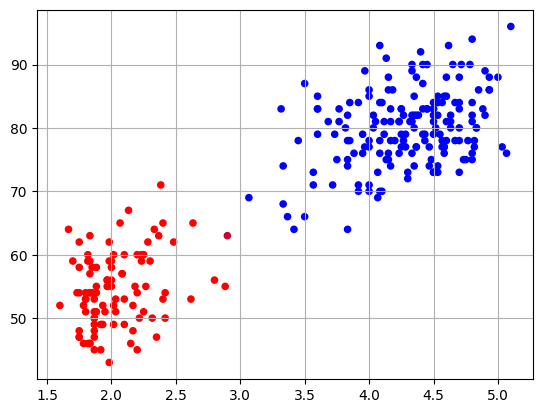

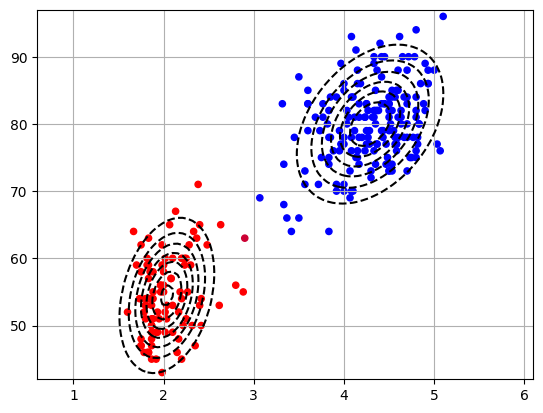

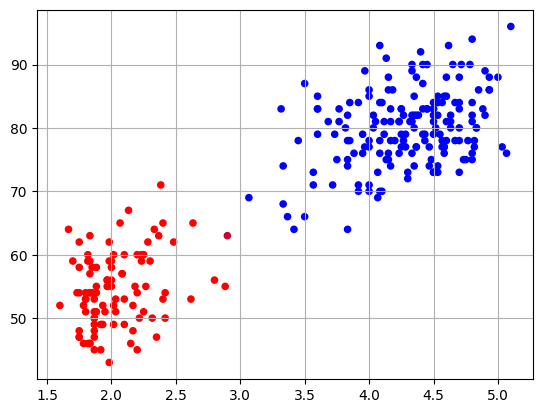

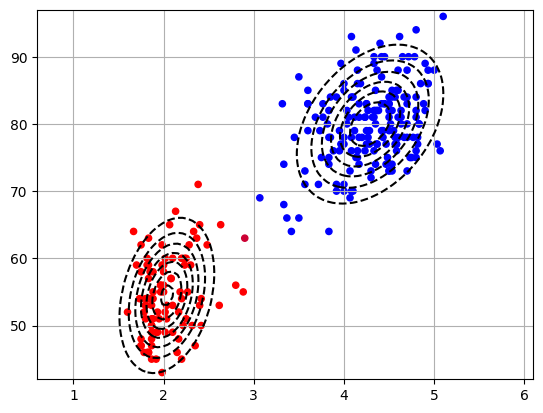

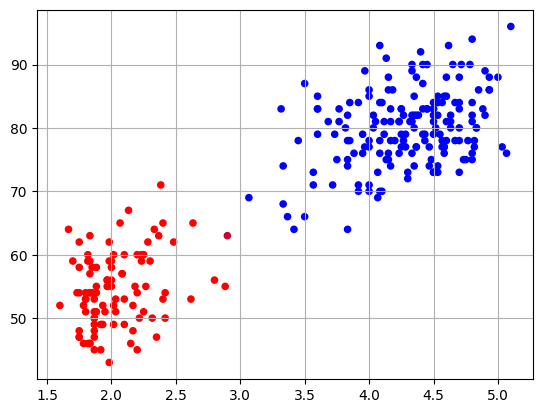

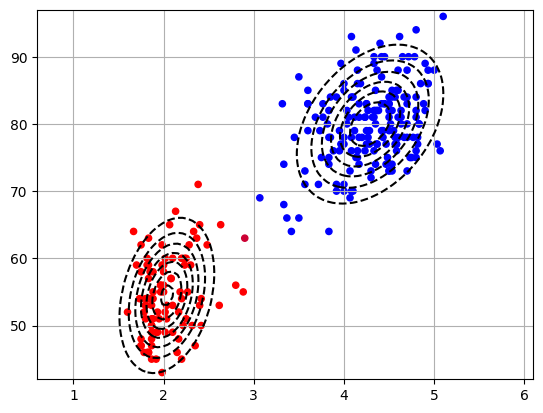

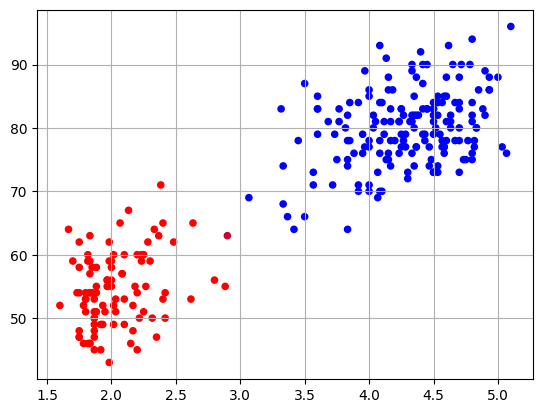

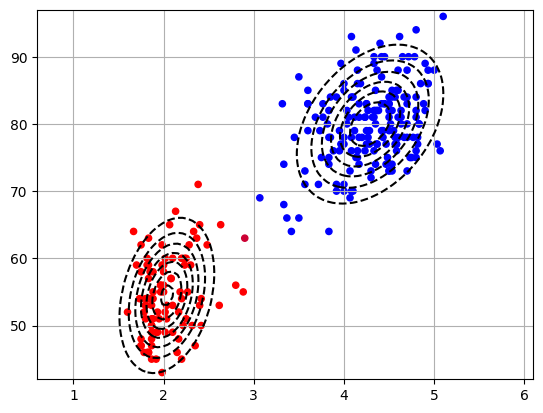

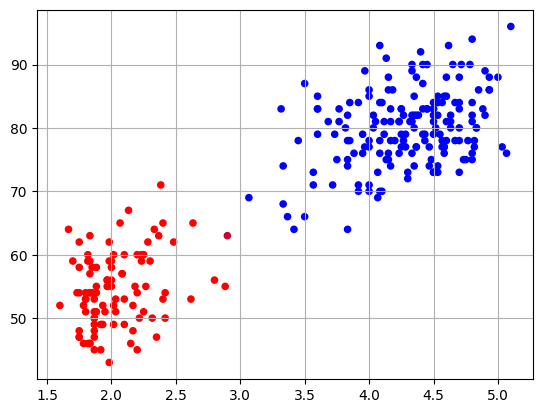

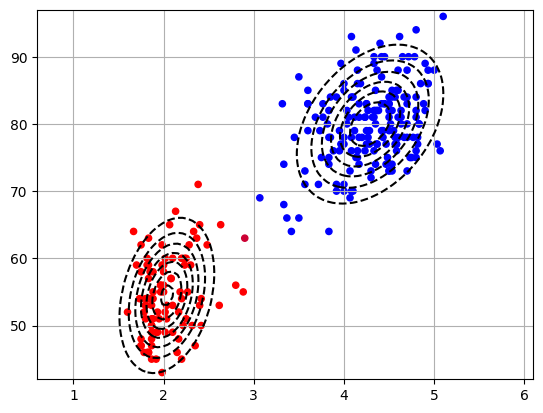

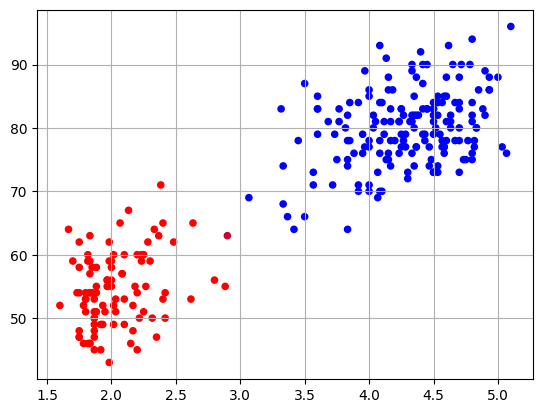

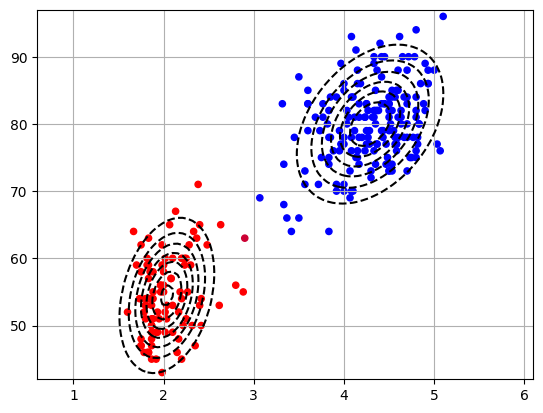

In [ ]:
mus, sigmas, Pis, gamma = emAlgo.run()

## Question 5

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Feb 25 23:32:28 2021

@author: satya
"""

import numpy as np

ta = 0.1   # bias of coina
tb = 0.8   # BIAS of coinb

pi=0.4

d = 25
n= 100     #total samples
z = np.zeros(n) #hidden A =0 B=1
x = np.zeros(n) #number of heads
for i in range(n):
    if np.random.uniform() <pi:
        x[i]  = np.random.binomial(d,ta)
    else:
        x[i]  = np.random.binomial(d,tb)
        z[i]=1

## forget zs
currAEst = 0.51 #beta or uniform choices are ok
currBEst = 0.534
piEst =0.5

repeatcount = 1000  # instead of checking for convergence
gammaiA = np.zeros(n)
gammaiB = np.zeros(n)
for i in range(repeatcount):
    ## EStep starts
    for j in range(n):
        gammaiA[j] = piEst* np.power(currAEst,x[j]) *np.power(1-currAEst,d-x[j])
        gammaiA[j] /= (piEst*np.power(currAEst,x[j]) *np.power(1-currAEst,d-x[j]) + (1-piEst)* np.power(currBEst,x[j]) *np.power(1-currBEst,d-x[j]) )
        gammaiB[j] = 1 - gammaiA[j]
    numA = denA = numB = denB = 0
    #Estep ends

    #MStep starts
    for k in range(n):
        numA += gammaiA[k]*x[k]
        numB += gammaiB[k]*x[k]
        denA += gammaiA[k]*d
        denB += gammaiB[k]*d
    currAEst = numA/denA
    currBEst = numB/denB
    piEst = sum(gammaiA)/n
    #Msteps ends

print(currAEst,currBEst)
print(sum(gammaiA)/n)

0.11444445366441665 0.8000000011214585
0.3600000058885432


In [ ]:
cluster_assignments = np.argmax(np.concatenate((np.array(gammaiA)[np.newaxis,:].T,np.array(gammaiB)[np.newaxis,:].T),axis=1),axis=1)

In [ ]:
accuracy = np.sum(cluster_assignments==z)/len(z)

In [ ]:
accuracy

1.0

[Text(0.5, 1.0, 'The given Samples are plotted here with hue as the assignment and y position as the original label.')]

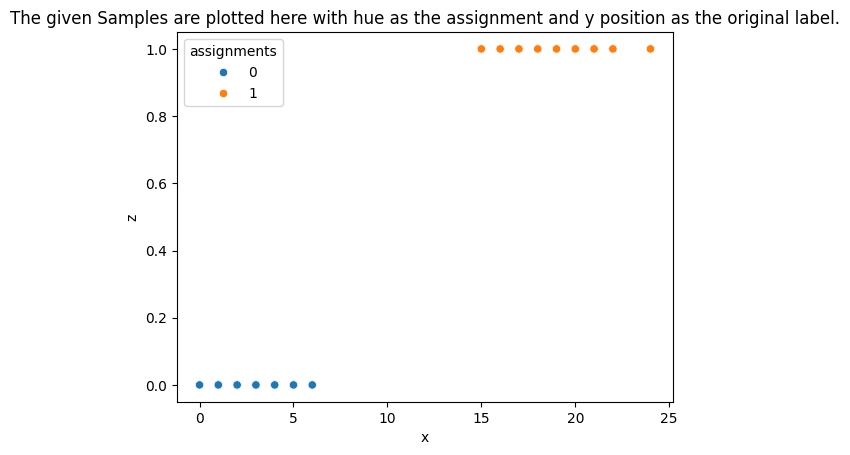

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
data = {"x":x,"assignments":cluster_assignments,"z":z,"ind":np.arange(1,len(x)+1)}
df = pd.DataFrame(data = data)
sns.scatterplot(data = df,x="x",y="z",hue="assignments").set(title="The given Samples are plotted here with hue as the assignment and y position as the original label.")

## Question 6

### Importing the Necesssary Modules

In [ ]:
modules = "numpy,pandas,matplotlib,sklearn,fetch_openml,tqdm" # @param {type:"string"}
mods = modules.split(",")
for i in mods:
  if i=="numpy":
    import numpy as np
  if i=="pandas":
    import pandas as pd
  if i=="matplotlib":
    import matplotlib.pyplot as plt
  if i=="sklearn":
    import sklearn
  if i=="fetch_openml":
    from sklearn.datasets import fetch_openml
  if i=="tqdm":
    from tqdm import tqdm
  if i=="cupy":
    import cupy as np

### Class for dataset Preparation and EM algorithm

#### The E-step Function



```
def Estep(self):
    for i in range(len(self.X)):
      original_values = self.Pis * np.prod((((2*self.Probs.T)**(self.X[i][np.newaxis,:]))).T, axis=0) * np.prod((((2*(1 - self.Probs.T))**(1 - self.X[i][np.newaxis,:]))).T, axis=0)
      max_value = np.max(original_values)
      scaled_values = original_values / max_value
      sum_scaled_values = np.sum(scaled_values)
      normalized_values = scaled_values / sum_scaled_values
      self.gamma[i] = normalized_values
```




#### The M-step Function



```
def Mstep(self):
    self.Pis = np.sum(self.gamma,axis=0)/len(self.X)
    Probsn = np.random.rand(len(self.clusters),len(self.X[0]))
    for k in range(len(self.clusters)):
        num = 0
        deno = 0
        for i in range(len(self.X)):
          num+=self.gamma[i][k]*self.X[i]
          deno+=self.gamma[i][k]
        Probsn[k] = num/deno
    self.Probs = Probsn.T.copy()
    del Probsn
```



In [ ]:
class EMMNIST:
  def __init__(self,clusters):
    self.X,self.y,self.mnist,self.Pis, self.Probs,self.gamma = None, None, None, None, None, None
    self.clusters = clusters
    self.mus,self.clusterpoints = None,None
    self.choice = None
  def dataset_download(self,choice):
    from sklearn.datasets import load_digits
    self.choice = choice
    if choice==0:
      self.mnist = load_digits()
    else:
      self.mnist = fetch_openml("mnist_784")
  def undersample_dataframe(self,df, label_column):
    counts = df[label_column].value_counts()
    min_count = counts.min()
    sampled_dfs = []
    for label, group in df.groupby(label_column):
        sampled_dfs.append(group.sample(min_count))
    return pd.concat(sampled_dfs)
  def initialize_data(self):
    (self.X,self.y) = (self.mnist.data,self.mnist.target)
    if self.choice==1:
      self.X = self.X.to_numpy()
    if self.choice==1:
      self.X[self.X<128]=0
      self.X[self.X>=128]=1
    else:
      self.X = pd.DataFrame(self.X)
      self.X["y"] = self.y
      # self.X = self.undersample_dataframe(self.X,"y")
      self.y = self.X["y"]
      self.X = self.X.drop("y",axis=1)
      self.X = self.X.to_numpy()
      self.X[self.X<8]=0
      self.X[self.X>=8]=1
    self.X = pd.DataFrame(self.X)
    self.X["y"] = self.y
    y_values = self.clusters
    if self.choice==1:
      self.X = self.X.query('y in @y_values')
    (self.X,self.y) = (self.X.drop("y",axis=1).to_numpy(),np.array(self.X["y"]))
    self.Pis = np.ones(len(self.clusters)) / len(self.clusters)
    self.Probs = np.random.rand(len(self.X[0]),len(self.clusters))
    self.gamma = np.zeros((len(self.X), len(self.clusters)))
  def plotdatapoint(self,i):
    if self.choice==1:
      plt.imshow(self.X[i].reshape(28,28),cmap='binary')
      plt.axis('off')
      plt.show()
    else:
      plt.imshow(self.X[i].reshape(8,8),cmap='binary')
      plt.axis('off')
      plt.show()
  def Estep(self):
    for i in range(len(self.X)):
      original_values = self.Pis * np.prod(((2*(self.Probs.T)**(self.X[i][np.newaxis,:]))).T, axis=0) * np.prod((((2*(1 - self.Probs.T))**(1 - self.X[i][np.newaxis,:]))).T, axis=0)
      self.gamma[i] = original_values/np.sum(original_values)
  def Mstep(self):
    self.Pis = np.sum(self.gamma,axis=0)/len(self.X)
    Probsn = np.random.rand(len(self.clusters),len(self.X[0]))
    for k in range(len(self.clusters)):
        num = 0
        deno = 0
        for i in range(len(self.X)):
          num+=self.gamma[i][k]*self.X[i]
          deno+=self.gamma[i][k]
        Probsn[k] = num/deno
    self.Probs = Probsn.T.copy()
    del Probsn
  def train(self,max_iters=40,tolerance=1e-12):
    noofclusters,noofpoints = len(self.clusters),len(self.X)
    for iter in tqdm(range(max_iters)):
      Pis_old,Probs_old = self.Pis.copy(),self.Probs.copy()
      self.Estep()
      self.Mstep()
      if np.max(np.abs(self.Pis - Pis_old)) < tolerance and np.max(np.abs(self.Probs - Probs_old)) < tolerance:
        print("EM Algorithm Converged Successfully!!!")
        print(f"New Changes after training {max_iters} iterations are:")
        print((np.max(np.abs(self.Pis - Pis_old)),np.max(np.abs(self.Probs - Probs_old))))
        break
  def clusterize(self):
    bernoulli_points = self.X
    feat,temp,count = len(self.clusters),[],[]
    for i in range(feat):
      if self.choice==1:
        temp.append(np.zeros(784))
      else:
        temp.append(np.zeros(64))
      count.append(0)
    for i in range(len(self.X)):
      temp[np.argmax(self.gamma[i])] = temp[np.argmax(self.gamma[i])] + self.X[i]
      count[np.argmax(self.gamma[i])]+=1
    self.mus = []
    for i in range(len(count)):
      self.mus.append(np.array(temp[i])/count[i])
    self.mus = np.array(self.mus)
    self.clusterpoints = np.array(count)
  def plotclusteraverages(self):
    indices = []
    for i in range(len(self.clusters)):
      indices.append(i+1)
    num_plots = len(indices)
    fig, axes = plt.subplots(1, num_plots, figsize=(15, 5))
    for ax, i in zip(axes, indices):
        result_image = self.mus[i-1]
        if self.choice==1:
          result_image = result_image.reshape(28, 28)
        else:
          result_image = result_image.reshape(8, 8)
        ax.imshow(result_image, cmap='binary')
        ax.set_title(f'Cluster Average of Cluster {i}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
  def sample_multivariate_bernoulli(self,cluster):
    probabilities = self.Probs.T[cluster]
    probabilities = np.clip(probabilities, 0, 1)
    sample = np.random.rand(len(probabilities)) < probabilities
    return sample.astype(int)
  def gennewsamples(self,cluster):
    if self.choice==1:
      plt.imshow(self.sample_multivariate_bernoulli(cluster).reshape(28,28),cmap='binary')
      plt.title(f"The Generated Sample From Cluster {cluster}")
      plt.axis('off')
      plt.show()
    else:
      plt.imshow(self.sample_multivariate_bernoulli(cluster).reshape(8,8),cmap='binary')
      plt.title(f"The Generated Sample From Cluster {cluster}")
      plt.axis('off')
      plt.show()
  def generateallaverages(self,points):
    if self.choice==1:
      num_clusters = len(self.clusters)
      fig, axes = plt.subplots(1, num_clusters, figsize=(15, 3))
      for cluster_index in range(num_clusters):
          temp = np.zeros(784)
          for _ in range(points):
              temp += self.sample_multivariate_bernoulli(cluster_index)
          temp_avg = temp / points
          axes[cluster_index].imshow(temp_avg.reshape(28, 28), cmap='binary')
          axes[cluster_index].set_title(f'Cluster {cluster_index+1}')
          axes[cluster_index].axis('off')
      plt.show()
    else:
      num_clusters = len(self.clusters)
      fig, axes = plt.subplots(1, num_clusters, figsize=(15, 3))
      for cluster_index in range(num_clusters):
          temp = np.zeros(64)
          for _ in range(points):
              temp += self.sample_multivariate_bernoulli(cluster_index)
          temp_avg = temp / points
          axes[cluster_index].imshow(temp_avg.reshape(8, 8), cmap='binary')
          axes[cluster_index].set_title(f'Cluster {cluster_index+1}')
          axes[cluster_index].axis('off')
      plt.show()


### Initializing the Estimator and Downloading the Data

In [ ]:
estimator = EMMNIST(['2','3','4','6','1','7','5','8','9','0'])
estimator.dataset_download(0)
estimator.initialize_data()

### Training the Estimator

In [ ]:
MaxIterations = 400 # @param {type:"slider", min:0, max:100, step:1}
Tolerance = 1e-14 # @param {type:"slider", min:1e-14, max:1, step:1e-13}

estimator.train(max_iters=MaxIterations,tolerance=Tolerance)

100%|██████████| 400/400 [01:15<00:00,  5.31it/s]


### Clusterwise Averages

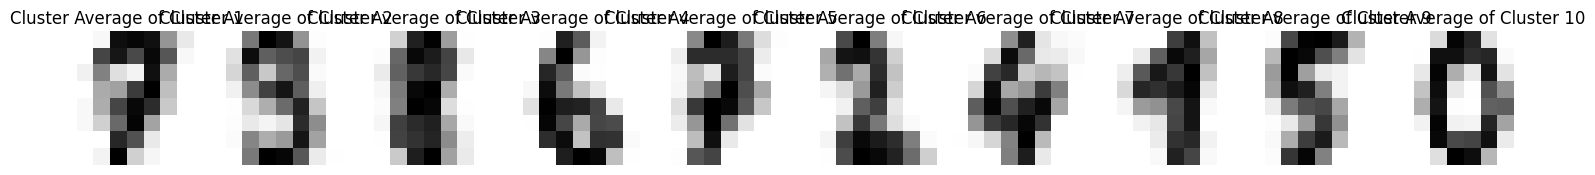

In [ ]:
estimator.clusterize()
estimator.plotclusteraverages()

In [ ]:
estimator.gamma[0]

array([0.00000000e+00, 9.01324963e-09, 2.74276783e-15, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.90781522e-09, 0.00000000e+00,
       0.00000000e+00, 9.99999989e-01])

In [ ]:
estimator.y

array([0, 1, 2, ..., 8, 9, 8])

In [ ]:
predclasses = [7,9,8,6,3,2,4,1,5,0]

In [ ]:
assignments = np.argmax(estimator.gamma,axis=1)

In [ ]:
assignments

array([9, 2, 2, ..., 2, 1, 1])

In [ ]:
for i in range(len(assignments)):
    assignments[i] = predclasses[assignments[i]]

In [ ]:
accuracy = np.sum(assignments==estimator.y)/len(assignments)
accuracy

0.6527545909849749

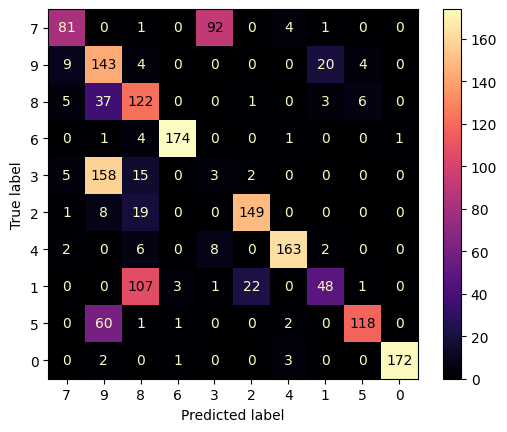

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(estimator.y, assignments, labels=predclasses)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=predclasses)
disp.plot(cmap="magma")
plt.show()

In [ ]:
misclassified = (1-accuracy)*len(estimator.gamma)

In [ ]:
print("Total No of Misclassified Points are:",int(misclassified))
print("Total No of Correctly classified Points are:",len(estimator.gamma)-int(misclassified))

Total No of Misclassified Points are: 624
Total No of Correctly classified Points are: 1173


## Question 7

### Importing the Necessary Modules

In [ ]:
import numpy as np
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
import math

### Class which contain the following classifiers:

1. Bayes Classifier
2. Neyman Pearson Classifier
3. Min Max Classifier

Apart from this, it also evaluate the performance of each of the classifiers. It also generates the ROC Curve needed during Neyman Pearson Classifier

In [ ]:
class Classifiers:

  def __init__(self, P, mean0, sigma0, mean1, sigma1, dataSize = 1000000, alpha = 0.1):
    self.P0 = P
    self.P1 = 1 - P
    self.mean0 = mean0
    self.sigma0 = sigma0
    self.mean1 = mean1
    self.sigma1 = sigma1
    self.dataSize = dataSize
    self.alpha = alpha

  def gaussian_distribution(self, x, mean, std_dev):
    return (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)

  def phi(self, x):
    return norm.cdf(x)

  def inverse_phi(self, x):
    return norm.ppf(x)

  def generateData(self):
    y = []
    temp1 = int(self.P1 * self.dataSize)
    temp2 = int(self.P0 * self.dataSize)
    for i in range(temp1):
      y.append(1)
    for i in range(temp2):
      y.append(0)
    y = np.random.permutation(y)
    x = []
    for i in range(self.dataSize):
      if (y[i] == 0):
        x.append(np.random.normal(self.mean0, self.sigma0, 1))
      else :
        x.append(np.random.normal(self.mean1, self.sigma1, 1))
    x = np.array(x)
    data = []
    for i in range(self.dataSize):
      pt = [x[i], y[i]]
      data.append(pt)
    return x, y, data

  def BayesClassifier(self):
    h_x = []
    x, y, data = self.generateData()
    for i in range(self.dataSize):
      f0_x = self.gaussian_distribution(x[i], self.mean0, self.sigma0)
      f1_x = self.gaussian_distribution(x[i], self.mean1, self.sigma1)
      sum = self.P0*f0_x + self.P1*f1_x
      q0_x = (self.P0*f0_x)/sum
      q1_x = (self.P1*f1_x)/sum
      ans = 0
      if (q0_x < q1_x):
        ans = 1
      h_x.append(ans)
      data[i].append(ans)
    return y, h_x, data

  def computeBayesClassifierPerformance(self):
    y, h_x, data = self.BayesClassifier()
    FP = 0
    TP = 0
    correct_pred = 0
    for i in range(self.dataSize):
      if (y[i] == 0 and h_x[i] == 1) :
        FP += 1
      if (y[i] == 1 and h_x[i] == 1) :
        TP += 1
      if (y[i] == h_x[i]):
        correct_pred += 1
    accuracy = correct_pred/self.dataSize
    return FP, TP, accuracy

  def MinMaxClassifier(self):
    h_x = []
    x, y, data = self.generateData()
    decision_boundary = (self.mean0 + self.mean1)/2
    for i in range(self.dataSize):
      if (x[i] >= decision_boundary):
        h_x.append(1)
      else:
        h_x.append(0)
    return y, h_x

  def computeMinMaxClassifierPerformance(self):
    y, h_x = self.MinMaxClassifier()
    FP = 0
    TP = 0
    correct_pred = 0
    for i in range(self.dataSize):
      if (y[i] == 0 and h_x[i] == 1) :
        FP += 1
      if (y[i] == 1 and h_x[i] == 1) :
        TP += 1
      if (y[i] == h_x[i]):
        correct_pred += 1
    accuracy = correct_pred/self.dataSize
    return FP, TP, accuracy

  def NeymannPearsonClassifier(self):
    h_x = []
    x, y, data = self.generateData()
    decision_boundary = (self.sigma0 * self.inverse_phi(1 - self.alpha)) + self.mean0
    for i in range(self.dataSize):
      if (x[i] >= decision_boundary):
        h_x.append(1)
      else:
        h_x.append(0)
    return y, h_x

  def computeNeymannPearsonClassifierPerformance(self):
    y, h_x = self.NeymannPearsonClassifier()
    FP = 0
    TP = 0
    correct_pred = 0
    for i in range(self.dataSize):
      if (y[i] == 0 and h_x[i] == 1) :
        FP += 1
      if (y[i] == 1 and h_x[i] == 1) :
        TP += 1
      if (y[i] == h_x[i]):
        correct_pred += 1
    accuracy = correct_pred/self.dataSize
    return FP, TP, accuracy

  def getCorrectDetection(self, I1):
    val1 = self.mean0 - self.mean1
    val1 /= self.sigma0
    val2 = self.inverse_phi(1 - I1)
    val = val1 + val2
    val = self.phi(val)
    I2 = 1 - val
    return I2

  def getROCCurve(self):
    false_alarms = np.linspace(0, 1, 1000)
    correct_detection = []
    for i in range(len(false_alarms)):
      correct_detection.append(self.getCorrectDetection(false_alarms[i]))
      plt.scatter(false_alarms[i], self.getCorrectDetection(false_alarms[i]))
    plt.title("ROC Curve")
    plt.xlabel("False Alarm")
    plt.ylabel("Correct Detection")
    plt.show()

### Calling the class by applying necessary parameters

In [ ]:
question7 = Classifiers(0.95, 0, 1, 1, 1, 10000, alpha=0.1)

In [ ]:
question7.computeBayesClassifierPerformance()

(3, 6, 0.9503)

In [ ]:
question7.computeNeymannPearsonClassifierPerformance()

(971, 168, 0.8697)

In [ ]:
question7.computeMinMaxClassifierPerformance()

(2865, 357, 0.6992)

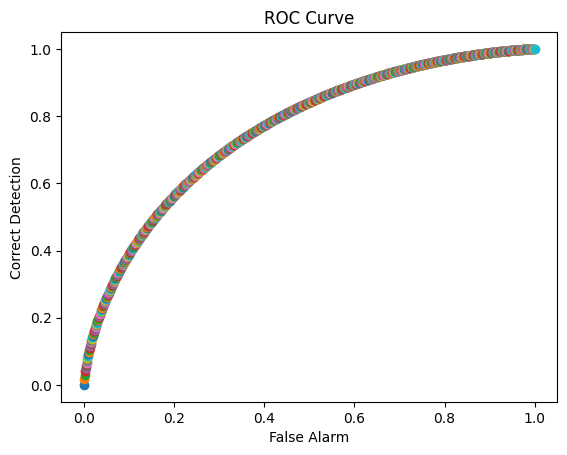

In [ ]:
question7.getROCCurve()